# Makemore Parte 2 — MLP con Embeddings de Caracteres

Basado en la clase de Andrej Karpathy y el paper **"A Neural Probabilistic Language Model"** (Bengio et al., 2003).

Se reemplaza el bigrama (1 carácter de contexto) por un **MLP** que usa los últimos 3 caracteres para predecir el siguiente. La mejora clave es aprender **embeddings** densos para cada carácter en lugar de one-hot vectors dispersos.

**Arquitectura:**
```
contexto (3 chars) → lookup en tabla C → embeddings → capa oculta (tanh) → logits → softmax → probabilidades
```

**Flujo del notebook:**
1. Construir el dataset con ventana de contexto de tamaño 3
2. Dividir en train / dev / test
3. Explorar la arquitectura del MLP paso a paso
4. Entrenar con minibatches y learning rate scheduling
5. Evaluar y visualizar los embeddings aprendidos
6. Muestrear nombres del modelo entrenado

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 1. Construcción del Dataset con Ventana de Contexto

En lugar de bigramas (contexto de 1 carácter), ahora usamos `block_size = 3` caracteres de contexto.

Para cada palabra, deslizamos una ventana de tamaño 3 y generamos pares `(X, Y)`:
- `X`: los últimos 3 caracteres vistos (índices enteros)
- `Y`: el siguiente carácter a predecir

Por ejemplo, para `"emma"`:
```
[., ., .]  →  e
[., ., e]  →  m
[., e, m]  →  m
[e, m, m]  →  a
[m, m, a]  →  .
```
`X` tiene forma `(N, 3)` e `Y` forma `(N,)`, donde `N` es el total de bigramas en el dataset.

In [5]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## 2. División Train / Dev / Test

Se divide el dataset aleatoriamente (con semilla fija para reproducibilidad):
- **80% Train** (`Xtr`, `Ytr`): para ajustar los pesos con gradiente descendente
- **10% Dev / Validation** (`Xdev`, `Ydev`): para evaluar hiperparámetros (arquitectura, learning rate, etc.) sin tocar el test set
- **10% Test** (`Xte`, `Yte`): evaluación final única — no se usa durante el desarrollo

Esta separación evita que el modelo "memorice" los datos y nos permite detectar overfitting.

In [8]:
C = torch.randn((27, 2))

## 3. Arquitectura del MLP — Paso a Paso

### Tabla de Embeddings `C`

`C` es una matriz de forma `(27, 2)`: cada uno de los 27 caracteres tiene un **embedding de 2 dimensiones** (vector aprendible en un espacio continuo).

`C[X]` hace un lookup: reemplaza cada índice de carácter por su vector de 2 dimensiones.  
Resultado: `emb` de forma `(N, 3, 2)` — para cada ejemplo, 3 caracteres de contexto, cada uno con 2 dimensiones.

> En el entrenamiento final se usa dimensión 10 en lugar de 2 para mayor capacidad.

In [9]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [10]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

### Capa Oculta

`emb.view(-1, 6)` aplana los 3 embeddings de 2 dims en un vector de 6 dims por ejemplo.  
Luego una capa lineal: `h = tanh(emb_flat @ W1 + b1)`

- `W1`: forma `(6, 100)` — proyecta de 6 dims a 100 neuronas ocultas
- `b1`: forma `(100,)` — bias de la capa oculta
- `tanh`: introduce no-linealidad, acotando la salida entre -1 y 1

> En el modelo final: `(30, 200)` — 3 chars × 10 dims de embedding = 30 inputs, 200 neuronas ocultas.

In [11]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [12]:
h.shape

torch.Size([228146, 100])

In [13]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

### Capa de Salida y Softmax Manual

`logits = h @ W2 + b2` — proyecta las 100 neuronas ocultas a 27 logits (uno por carácter posible).

La conversión a probabilidades se hace manualmente:
```python
counts = logits.exp()                        # equivalente a e^logits
prob   = counts / counts.sum(1, keepdim=True) # normalizar → suma 1 por fila
loss   = -prob[torch.arange(len(Y)), Y].log().mean()  # NLL promedio
```

Esto es equivalente a `F.cross_entropy(logits, Y)`, que hace los 3 pasos en una sola operación (más numéricamente estable). En el entrenamiento real se usa `F.cross_entropy` directamente.

In [14]:
logits = h @ W2 + b2

In [15]:
logits.shape

torch.Size([228146, 27])

In [16]:
counts = logits.exp()

In [17]:
prob = counts / counts.sum(1, keepdims=True)

In [18]:
prob.shape

torch.Size([228146, 27])

In [20]:
loss = -prob[torch.arange(len(Y)), Y].log().mean()
loss

tensor(15.6287)

In [ ]:
# ------------ now made respectable :) ---------------

## 4. Entrenamiento Completo

Ahora se usa la configuración final:
- **Embeddings de dim 10** (`C`: 27×10)
- **200 neuronas ocultas** (`W1`: 30×200, `b1`: 200)
- **Salida** (`W2`: 200×27, `b2`: 27)
- Total: **~11,897 parámetros**

### Minibatches
En lugar de usar todo el dataset en cada paso, se toman muestras aleatorias de 32 ejemplos (`ix = torch.randint(..., (32,))`). Esto hace el entrenamiento mucho más rápido y agrega ruido que ayuda a escapar de mínimos locales.

### Learning Rate Scheduling
Se usa un LR alto (`0.1`) las primeras 100k iteraciones para bajar rápido, luego se reduce a `0.01` para afinar. Esto es una forma simple de **decay del learning rate**.

In [21]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [22]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [23]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [24]:
for p in parameters:
  p.requires_grad = True

In [25]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [26]:
lri = []
lossi = []
stepi = []

In [27]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

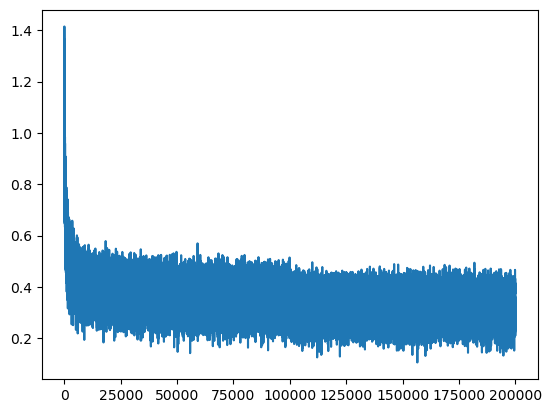

In [28]:
plt.plot(stepi, lossi)

In [29]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1211, grad_fn=<NllLossBackward0>)

## 5. Evaluación: Train vs Dev Loss

Se evalúa la pérdida sobre todo el set de entrenamiento y luego sobre el set de validación (`Xdev`).

- **Train loss ~2.12** — qué tan bien ajusta los datos de entrenamiento
- **Dev loss ~2.16** — qué tan bien generaliza a datos no vistos

La pequeña diferencia indica que el modelo **no está overfittando** significativamente. Si dev loss fuera mucho mayor que train loss, habría overfitting.

In [30]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1582, grad_fn=<NllLossBackward0>)

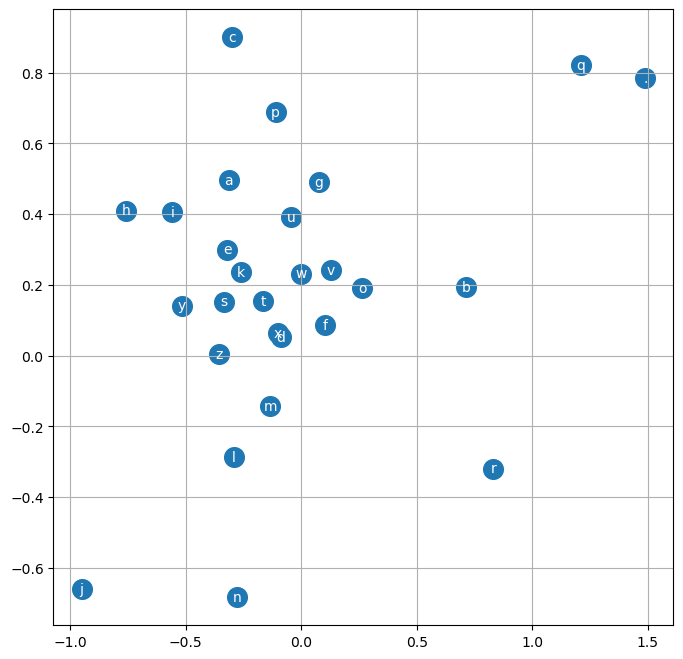

In [31]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

## 6. Visualización de los Embeddings Aprendidos

Se visualizan las primeras 2 dimensiones de `C` (la tabla de embeddings). Cada punto es un carácter.

Los caracteres que aparecen **agrupados** son aquellos que el modelo aprendió a tratar de forma similar — es decir, que aparecen en contextos parecidos dentro de los nombres. Por ejemplo, las vocales tienden a agruparse entre sí.

> Esto es el modelo aprendiendo estructura del lenguaje de forma no supervisada, solo a partir de predecir el siguiente carácter.

In [32]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

## 7. Muestreo de Nombres del Modelo Entrenado

Para generar un nombre:
1. Empezar con contexto `[., ., .]` (3 tokens de inicio)
2. Hacer un forward pass para obtener probabilidades sobre los 27 caracteres
3. Muestrear el siguiente carácter con `torch.multinomial`
4. Agregar el carácter al contexto (deslizar la ventana) y repetir
5. Parar cuando se muestrea el token `.` (fin de nombre)

Los nombres generados (`carmah`, `amelle`, `quinn`...) suenan más plausibles que los del modelo de bigramas, gracias al contexto de 3 caracteres y a los embeddings aprendidos.

In [33]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [34]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amelle.
khiwmoni.
thildencessa.
jazhetna.
merynci.
aqui.
nellara.
chaiir.
kaleig.
dham.
joce.
quinn.
shous.
alian.
quinathon.
jaryni.
jaxen.
dura.
mel.
